# Incremental Flare Walkthrough
This notebook walks through the week-by-week flare check for `4FGL J2253.9+1609` using the repository's source-of-truth analysis code.

The workflow is:
1. Load the weekly light-curve data.
2. Recompute the quiescent background on the previous week's light curve.
3. Compare the newly added weekly point against `2 x` the previous quiescent background.
4. Mark each above-threshold point as a potential flare point.
5. Mark a flare after `3` potential flare points occur in a row.
6. Plot the light curve with the highlighted flare intervals.

In [1]:
from pathlib import Path
import sys
import importlib

from astropy.time import Time
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
PYTHON_FILES = ROOT / 'PythonFiles'
if str(PYTHON_FILES) not in sys.path:
    sys.path.insert(0, str(PYTHON_FILES))

import notebook_pipeline as npipe
npipe = importlib.reload(npipe)

SOURCE_NAME = '4FGL J2253.9+1609'
PERCENT = 0.3
FLARE_THRESHOLD_MULTIPLIER = 2.0
CONSECUTIVE_POINTS = 3

OUTPUT_DIR = ROOT / 'DownloadedLC' / 'incremental'
PLOT_PATH = OUTPUT_DIR / f"{SOURCE_NAME.replace(' ', '_')}_incremental_plot.png"
SCAN_PATH = OUTPUT_DIR / f"{SOURCE_NAME.replace(' ', '_')}_incremental_walkthrough.csv"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def mjd_to_datetime(values):
    converted = []
    for value in np.asarray(values, dtype=float):
        if np.isfinite(value):
            converted.append(Time(value, format='mjd').datetime)
        else:
            converted.append(pd.NaT)
    return pd.to_datetime(converted)

## 1. Load and Inspect the Time-Series Data
Load the weekly source database used by the notebook pipeline and inspect the weekly bins for the selected source.

In [ ]:
cadence_df = npipe.load_weekly_database()
sourcearray, time_values, flux_values, error_values, average_flux = npipe.build_source_arrays(
    cadence_df, SOURCE_NAME
)

source_df = pd.DataFrame(
    {
        'time_mjd': time_values,
        'flux': flux_values,
        'flux_error': error_values,
    }
)

print(f'Source: {SOURCE_NAME}')
print(f'Weekly bins available: {len(source_df)}')
print(f'Average weekly flux: {average_flux:.3e}')
source_df.head(10)

Source: 4FGL J2253.9+1609
Weekly bins available: 841
Average weekly flux: 1.282e-06


,time_mjd,flux,flux_error
0,54683.000012,3.410000e-06,9.930000e-08
1,54690.000012,2.600000e-06,8.750000e-08
2,54697.000012,3.010000e-06,9.690000e-08
3,54704.000012,3.160000e-06,1.070000e-07
4,54711.000012,2.500000e-06,1.110000e-07
...,...,...,...
836,60822.000012,5.620000e-07,6.150000e-08
837,60829.000012,6.670000e-07,6.310000e-08
838,60836.000012,4.590000e-07,4.960000e-08
839,60843.000012,6.480000e-07,5.370000e-08


## 2. Prepare Time Axes and Flare Interval Definitions
Run the incremental scan. Each row compares the previous week's light curve with the current week's light curve and evaluates the newly added point against `2 x` the previous quiescent background.

In [4]:
incremental_df = npipe.incremental_flare_scan(
    source_name=SOURCE_NAME,
    percent=PERCENT,
    flare_threshold_multiplier=FLARE_THRESHOLD_MULTIPLIER,
    consecutive_points=CONSECUTIVE_POINTS,
).copy()

incremental_df['date'] = mjd_to_datetime(incremental_df['new_point_mjd'])
incremental_df['flare_start_date'] = mjd_to_datetime(incremental_df['flare_start_mjd'])
incremental_df['flare_end_date'] = mjd_to_datetime(incremental_df['flare_end_mjd'])

incremental_df[[
    'current_bin_count',
    'new_point_mjd',
    'new_point_flux',
    'previous_quiescent_background',
    'flare_flux_threshold',
    'potential_flare_point',
    'consecutive_potential_flare_points',
    'flare_active',
]].head(12)

,current_bin_count,new_point_mjd,new_point_flux,previous_quiescent_background,flare_flux_threshold,potential_flare_point,consecutive_potential_flare_points,flare_active
0,2,54690.000012,0.000003,0.000001,0.000002,True,1,False
1,3,54697.000012,0.000003,0.000001,0.000002,True,2,False
2,4,54704.000012,0.000003,0.000001,0.000002,True,3,True
3,5,54711.000012,0.000003,0.000001,0.000002,True,4,True
4,6,54718.000012,0.000004,0.000001,0.000002,True,5,True
5,7,54725.000012,0.000004,0.000001,0.000002,True,6,True
6,8,54732.000012,0.000002,0.000001,0.000002,True,7,True
7,9,54739.000012,0.000003,0.000001,0.000002,True,8,True
8,10,54746.000012,0.000002,0.000001,0.000002,False,0,False
9,11,54753.000012,0.000001,0.000001,0.000002,False,0,False


## 3. Create a Boolean Mask for Highlighted Flaring Periods
Build a Boolean mask for the weekly points that belong to any flare-active interval and collect the interval boundaries for shading.

In [5]:
source_df['date'] = mjd_to_datetime(source_df['time_mjd'])
source_df['highlighted_flare_point'] = False

active_rows = incremental_df.loc[incremental_df['flare_active']].copy()
flare_intervals = []
if not active_rows.empty:
    interval_start = active_rows.iloc[0]
    interval_prev = active_rows.iloc[0]
    for _, row in active_rows.iloc[1:].iterrows():
        contiguous = int(row['current_bin_count']) == int(interval_prev['current_bin_count']) + 1
        same_start = np.isclose(row['flare_start_mjd'], interval_prev['flare_start_mjd'], atol=1e-6)
        if contiguous and same_start:
            interval_prev = row
            continue
        flare_intervals.append((float(interval_start['flare_start_mjd']), float(interval_prev['new_point_mjd'])))
        interval_start = row
        interval_prev = row
    flare_intervals.append((float(interval_start['flare_start_mjd']), float(interval_prev['new_point_mjd'])))

for start_mjd, end_mjd in flare_intervals:
    source_df.loc[source_df['time_mjd'].between(start_mjd, end_mjd), 'highlighted_flare_point'] = True

print(f'Potential flare points: {int(incremental_df["potential_flare_point"].sum())}')
print(f'Weeks in active flare state: {int(incremental_df["flare_active"].sum())}')
print(f'Identified flare intervals: {len(flare_intervals)}')
pd.DataFrame(
    {
        'flare_start_mjd': [item[0] for item in flare_intervals],
        'flare_end_mjd': [item[1] for item in flare_intervals],
        'flare_start_date': mjd_to_datetime([item[0] for item in flare_intervals]),
        'flare_end_date': mjd_to_datetime([item[1] for item in flare_intervals]),
    }
)

Potential flare points: 133
Weeks in active flare state: 84
Identified flare intervals: 12


,flare_start_mjd,flare_end_mjd,flare_start_date,flare_end_date
0,54690.000012,54739.000012,2008-08-12 00:00:01,2008-09-30 00:00:01
1,55068.000012,55131.000012,2009-08-25 00:00:01,2009-10-27 00:00:01
2,55145.000012,55264.000012,2009-11-10 00:00:01,2010-03-09 00:00:01
3,55278.000012,55341.000012,2010-03-23 00:00:01,2010-05-25 00:00:01
4,55453.000012,55621.000012,2010-09-14 00:00:01,2011-03-01 00:00:01
5,56811.000012,56888.000012,2014-06-03 00:00:01,2014-08-19 00:00:01
6,56902.000012,56923.000012,2014-09-02 00:00:01,2014-09-23 00:00:01
7,57000.000012,57014.000012,2014-12-09 00:00:01,2014-12-23 00:00:01
8,57287.000012,57301.000012,2015-09-22 00:00:01,2015-10-06 00:00:01
9,57315.000012,57343.000012,2015-10-20 00:00:01,2015-11-17 00:00:01


## 4. Plot the Full Signal with Highlighted Flare Regions
Plot the full weekly light curve, shade each active flare interval, and mark the weekly points that fall inside those intervals.

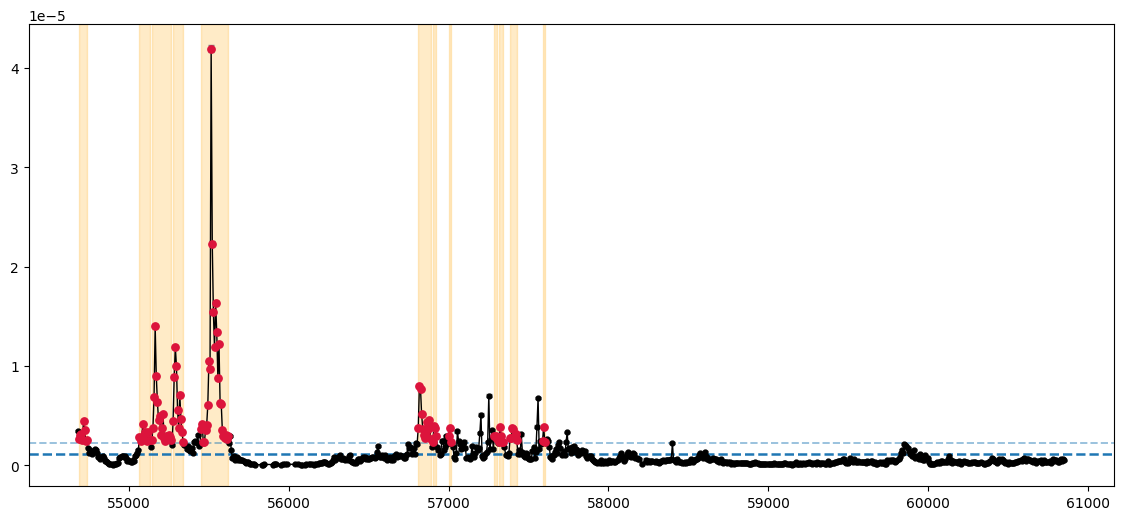

In [6]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.errorbar(
    source_df['time_mjd'],
    source_df['flux'],
    yerr=source_df['flux_error'],
    fmt='o-',
    color='black',
    ecolor='gray',
    linewidth=1.0,
    markersize=3.5,
    capsize=2,
    label='Weekly flux',
)

qb_series = incremental_df['previous_quiescent_background'].dropna()
if not qb_series.empty:
    qb_level = float(qb_series.iloc[-1])
    ax.axhline(
        qb_level,
        color='tab:blue',
        linestyle='--',
        linewidth=1.8,
        label='Quiescent background',
    )
    ax.axhline(
        2.0 * qb_level,
        color='tab:blue',
        linestyle='--',
        linewidth=1.4,
        alpha=0.45,
        label='2 x quiescent background',
    )

flare_points = source_df.loc[source_df['highlighted_flare_point']].copy()
if not flare_points.empty:
    ax.scatter(
        flare_points['time_mjd'],
        flare_points['flux'],
        color='crimson',
        s=28,
        zorder=4,
        label='Points inside flare intervals',
    )

for interval_index, (start_mjd, end_mjd) in enumerate(flare_intervals):
    ax.axvspan(
        start_mjd,
        end_mjd,
        color='orange',
        alpha=0.22,
        label='Highlighted flare interval' if interval_index == 0 else None,
    )

## 5. Add Labels, Legend, and Visual Refinements
Format the axes and annotate the final plot so the flare periods are easy to read.

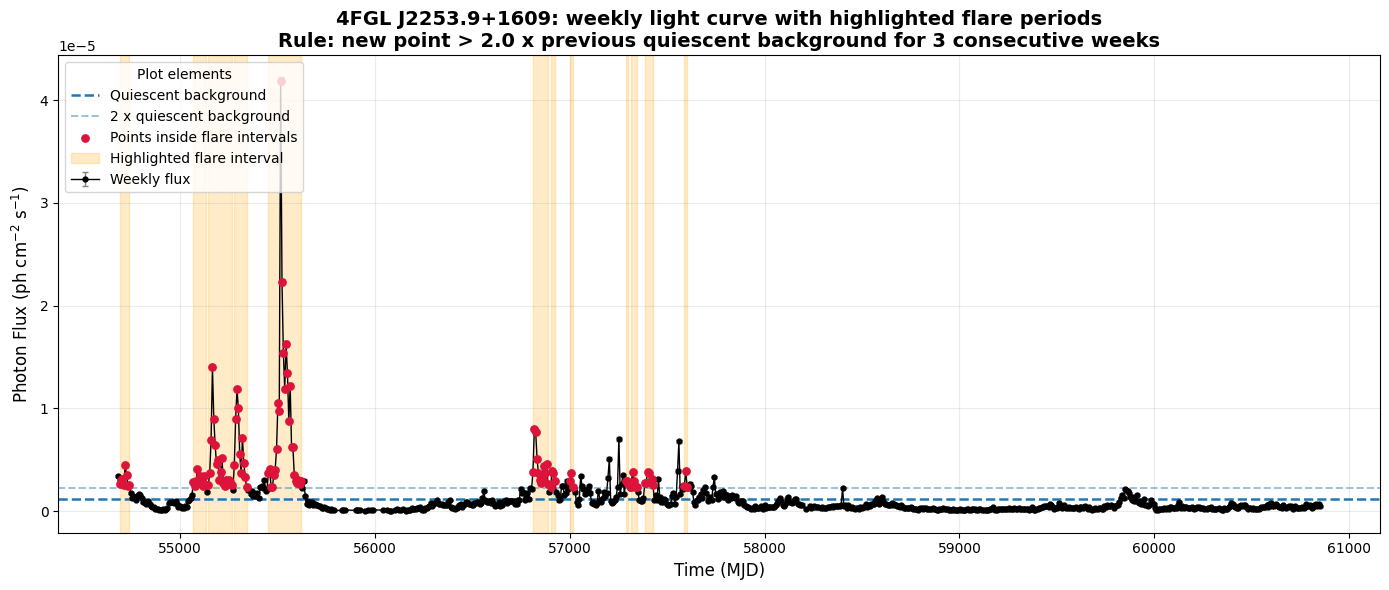

In [7]:
ax.set_title(
    f'{SOURCE_NAME}: weekly light curve with highlighted flare periods\n'
    f'Rule: new point > {FLARE_THRESHOLD_MULTIPLIER:.1f} x previous quiescent background for {CONSECUTIVE_POINTS} consecutive weeks',
    fontsize=14,
    fontweight='bold',
)
ax.set_xlabel('Time (MJD)', fontsize=12)
ax.set_ylabel(r'Photon Flux (ph cm$^{-2}$ s$^{-1}$)', fontsize=12)
ax.grid(alpha=0.25)
ax.legend(title='Plot elements', loc='upper left', frameon=True)
fig.tight_layout()
fig

## 5b. Zoom Into a Specific Flare Region
Use a narrow MJD range to inspect one flare in detail, including highlighted intervals and potential flare points.

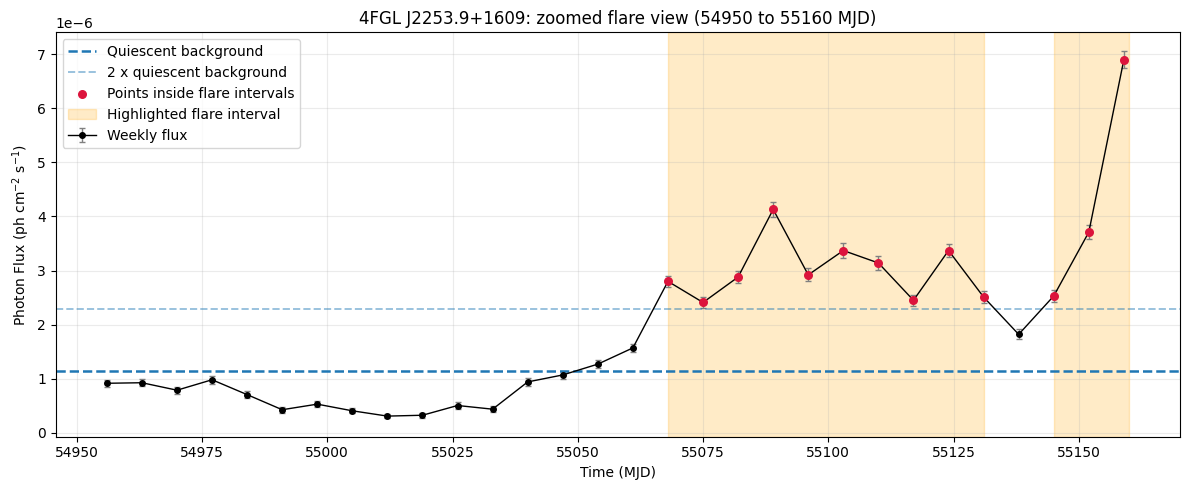

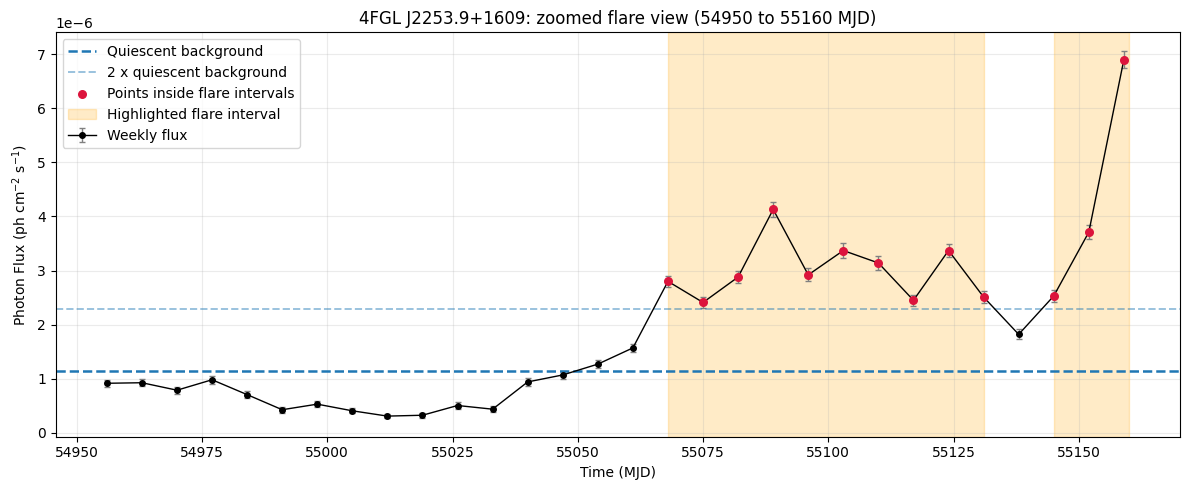

In [8]:
ZOOM_MJD_MIN = 54950
ZOOM_MJD_MAX = 55160

zoom_df = source_df.loc[source_df['time_mjd'].between(ZOOM_MJD_MIN, ZOOM_MJD_MAX)].copy()
zoom_flare_points = zoom_df.loc[zoom_df['highlighted_flare_point']].copy()

zoom_intervals = [
    (start_mjd, end_mjd)
    for (start_mjd, end_mjd) in flare_intervals
    if (end_mjd >= ZOOM_MJD_MIN and start_mjd <= ZOOM_MJD_MAX)
]

fig_zoom, ax_zoom = plt.subplots(figsize=(12, 5))
ax_zoom.errorbar(
    zoom_df['time_mjd'],
    zoom_df['flux'],
    yerr=zoom_df['flux_error'],
    fmt='o-',
    color='black',
    ecolor='gray',
    linewidth=1.0,
    markersize=4,
    capsize=2,
    label='Weekly flux',
)

qb_series = incremental_df['previous_quiescent_background'].dropna()
if not qb_series.empty:
    qb_level = float(qb_series.iloc[-1])
    ax_zoom.axhline(
        qb_level,
        color='tab:blue',
        linestyle='--',
        linewidth=1.8,
        label='Quiescent background',
    )
    ax_zoom.axhline(
        2.0 * qb_level,
        color='tab:blue',
        linestyle='--',
        linewidth=1.4,
        alpha=0.45,
        label='2 x quiescent background',
    )

if not zoom_flare_points.empty:
    ax_zoom.scatter(
        zoom_flare_points['time_mjd'],
        zoom_flare_points['flux'],
        color='crimson',
        s=30,
        zorder=4,
        label='Points inside flare intervals',
    )

for interval_index, (start_mjd, end_mjd) in enumerate(zoom_intervals):
    ax_zoom.axvspan(
        max(start_mjd, ZOOM_MJD_MIN),
        min(end_mjd, ZOOM_MJD_MAX),
        color='orange',
        alpha=0.22,
        label='Highlighted flare interval' if interval_index == 0 else None,
    )

ax_zoom.set_title(f'{SOURCE_NAME}: zoomed flare view ({ZOOM_MJD_MIN} to {ZOOM_MJD_MAX} MJD)')
ax_zoom.set_xlabel('Time (MJD)')
ax_zoom.set_ylabel(r'Photon Flux (ph cm$^{-2}$ s$^{-1}$)')
ax_zoom.grid(alpha=0.25)
ax_zoom.legend(loc='upper left', frameon=True)
fig_zoom.tight_layout()
fig_zoom

## 6. Export the Figure or Save the Notebook Output
Save the plot and the week-by-week flare table so they can be reused outside the notebook.

In [24]:
incremental_df.to_csv(SCAN_PATH, index=False)
fig.savefig(PLOT_PATH, dpi=150, bbox_inches='tight')

print(f'Saved flare scan table to: {SCAN_PATH}')
print(f'Saved flare plot to: {PLOT_PATH}')

incremental_df.tail(10)

Saved flare scan table to: /home/lkoo/projects/AutomationDetection/DownloadedLC/incremental/4FGL_J2253.9+1609_incremental_walkthrough.csv
Saved flare plot to: /home/lkoo/projects/AutomationDetection/DownloadedLC/incremental/4FGL_J2253.9+1609_incremental_plot.png


,Name,previous_bin_count,current_bin_count,new_point_mjd,new_point_flux,previous_point_flux,average_flux_full_series,previous_quiescent_background,previous_quiescent_background_error,current_quiescent_background,...,potential_flare_point,consecutive_potential_flare_points,flare_active,flare_start_mjd,flare_end_mjd,quiescent_background_origin,quiescent_background_cache_path,date,flare_start_date,flare_end_date
830,4FGL J2253.9+1609,831,832,60787.000012,4.520000e-07,6.470000e-07,0.000001,0.000001,2.942002e-09,0.000001,...,False,0,False,NaN,NaN,cache,/home/lkoo/projects/AutomationDetection/Downlo...,2025-04-22 00:00:01,NaT,NaT
831,4FGL J2253.9+1609,832,833,60794.000012,5.260000e-07,4.520000e-07,0.000001,0.000001,2.942002e-09,0.000001,...,False,0,False,NaN,NaN,cache,/home/lkoo/projects/AutomationDetection/Downlo...,2025-04-29 00:00:01,NaT,NaT
832,4FGL J2253.9+1609,833,834,60801.000012,5.500000e-07,5.260000e-07,0.000001,0.000001,2.942002e-09,0.000001,...,False,0,False,NaN,NaN,cache,/home/lkoo/projects/AutomationDetection/Downlo...,2025-05-06 00:00:01,NaT,NaT
833,4FGL J2253.9+1609,834,835,60808.000012,3.180000e-07,5.500000e-07,0.000001,0.000001,2.942002e-09,0.000001,...,False,0,False,NaN,NaN,cache,/home/lkoo/projects/AutomationDetection/Downlo...,2025-05-13 00:00:01,NaT,NaT
834,4FGL J2253.9+1609,835,836,60815.000012,3.730000e-07,3.180000e-07,0.000001,0.000001,2.942002e-09,0.000001,...,False,0,False,NaN,NaN,cache,/home/lkoo/projects/AutomationDetection/Downlo...,2025-05-20 00:00:01,NaT,NaT
835,4FGL J2253.9+1609,836,837,60822.000012,5.620000e-07,3.730000e-07,0.000001,0.000001,2.942002e-09,0.000001,...,False,0,False,NaN,NaN,cache,/home/lkoo/projects/AutomationDetection/Downlo...,2025-05-27 00:00:01,NaT,NaT
836,4FGL J2253.9+1609,837,838,60829.000012,6.670000e-07,5.620000e-07,0.000001,0.000001,2.942002e-09,0.000001,...,False,0,False,NaN,NaN,cache,/home/lkoo/projects/AutomationDetection/Downlo...,2025-06-03 00:00:01,NaT,NaT
837,4FGL J2253.9+1609,838,839,60836.000012,4.590000e-07,6.670000e-07,0.000001,0.000001,2.942002e-09,0.000001,...,False,0,False,NaN,NaN,cache,/home/lkoo/projects/AutomationDetection/Downlo...,2025-06-10 00:00:01,NaT,NaT
838,4FGL J2253.9+1609,839,840,60843.000012,6.480000e-07,4.590000e-07,0.000001,0.000001,2.942002e-09,0.000001,...,False,0,False,NaN,NaN,cache,/home/lkoo/projects/AutomationDetection/Downlo...,2025-06-17 00:00:01,NaT,NaT
839,4FGL J2253.9+1609,840,841,60850.000012,4.820000e-07,6.480000e-07,0.000001,0.000001,2.942002e-09,0.000001,...,False,0,False,NaN,NaN,cache,/home/lkoo/projects/AutomationDetection/Downlo...,2025-06-24 00:00:01,NaT,NaT


## 7. Dummy Light Curve: Feed Week-by-Week Into the Script
Create a synthetic weekly light curve with controlled flare-like segments, then run the **script** week-by-week to verify detection behavior.

In [9]:
import subprocess

DUMMY_DIR = ROOT / 'DownloadedLC' / 'incremental' / 'dummy_test'
DUMMY_DIR.mkdir(parents=True, exist_ok=True)

DUMMY_SOURCE = '4FGL DUMMY J9999.9+9999'
DUMMY_CACHE_PATH = DUMMY_DIR / 'dummy_qb_cache.csv'
DUMMY_FULL_DB_PATH = DUMMY_DIR / 'dummy_full_weekly.csv'

np.random.seed(42)
n_weeks = 24
mjd_start = 60000
baseline_flux = 3.0e-7
noise_sigma = 3.0e-8

dummy_flux = baseline_flux + np.random.normal(0.0, noise_sigma, size=n_weeks)
dummy_flux = np.clip(dummy_flux, 8.0e-8, None)

# Main 4-point flare-like segment (should trigger >= 3 consecutive potential points).
dummy_flux[10:14] = np.array([7.5e-7, 8.2e-7, 9.0e-7, 8.1e-7])

# Secondary short segment (2 points, should usually not trigger flare-active by itself).
dummy_flux[18:20] = np.array([7.0e-7, 7.3e-7])

dummy_err = np.full(n_weeks, 4.0e-8)
dummy_mjd = mjd_start + np.arange(n_weeks) * 7.0
dummy_tmin = ((dummy_mjd - npipe.MJDREFI) * npipe.SECS_IN_DAY).astype(float)
dummy_tmax = dummy_tmin + 7.0 * npipe.SECS_IN_DAY

dummy_df = pd.DataFrame(
    {
        'Unnamed: 0': np.arange(n_weeks),
        'source_name': DUMMY_SOURCE,
        'cadence': 'weekly',
        'tmin': dummy_tmin,
        'tmax': dummy_tmax,
        'photon_flux2': dummy_flux,
        'photon_flux_error2': dummy_err,
        'photon_index2': np.full(n_weeks, 2.0),
        'return_code2': np.zeros(n_weeks, dtype=int),
        'ts2': np.full(n_weeks, 40.0),
    }
)

dummy_df.to_csv(DUMMY_FULL_DB_PATH, index=False)
dummy_df.head(12)

,Unnamed: 0,source_name,cadence,tmin,tmax,photon_flux2,photon_flux_error2,photon_index2,return_code2,ts2
0,0,4FGL DUMMY J9999.9+9999,weekly,698976000.0,699580800.0,3.149014e-07,4.000000e-08,2.0,0,40.0
1,1,4FGL DUMMY J9999.9+9999,weekly,699580800.0,700185600.0,2.958521e-07,4.000000e-08,2.0,0,40.0
2,2,4FGL DUMMY J9999.9+9999,weekly,700185600.0,700790400.0,3.194307e-07,4.000000e-08,2.0,0,40.0
3,3,4FGL DUMMY J9999.9+9999,weekly,700790400.0,701395200.0,3.456909e-07,4.000000e-08,2.0,0,40.0
4,4,4FGL DUMMY J9999.9+9999,weekly,701395200.0,702000000.0,2.929754e-07,4.000000e-08,2.0,0,40.0
5,5,4FGL DUMMY J9999.9+9999,weekly,702000000.0,702604800.0,2.929759e-07,4.000000e-08,2.0,0,40.0
6,6,4FGL DUMMY J9999.9+9999,weekly,702604800.0,703209600.0,3.473764e-07,4.000000e-08,2.0,0,40.0
7,7,4FGL DUMMY J9999.9+9999,weekly,703209600.0,703814400.0,3.230230e-07,4.000000e-08,2.0,0,40.0
8,8,4FGL DUMMY J9999.9+9999,weekly,703814400.0,704419200.0,2.859158e-07,4.000000e-08,2.0,0,40.0
9,9,4FGL DUMMY J9999.9+9999,weekly,704419200.0,705024000.0,3.162768e-07,4.000000e-08,2.0,0,40.0


Weeks: 24
Max flux / baseline: 3.00x


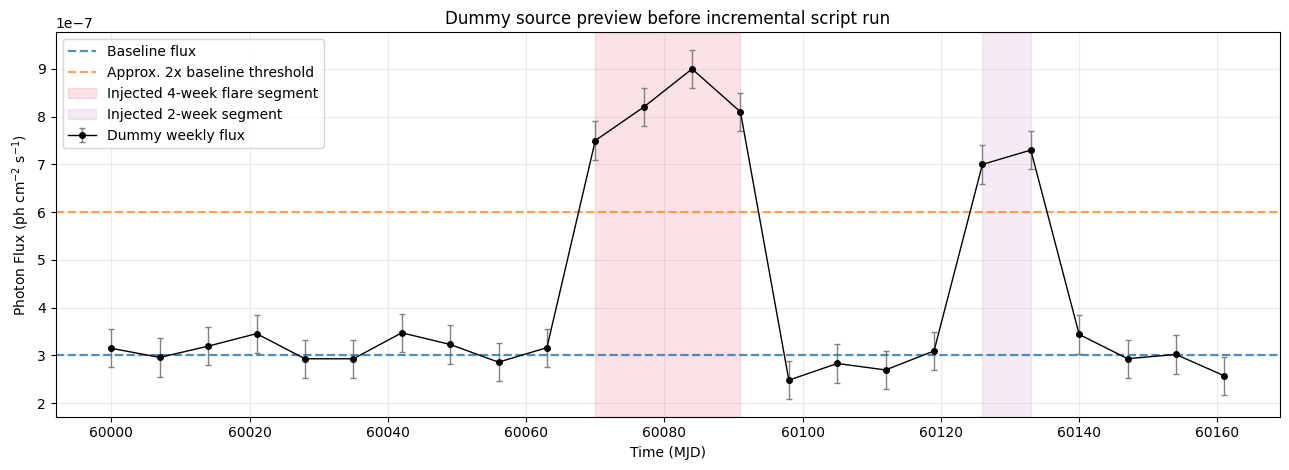

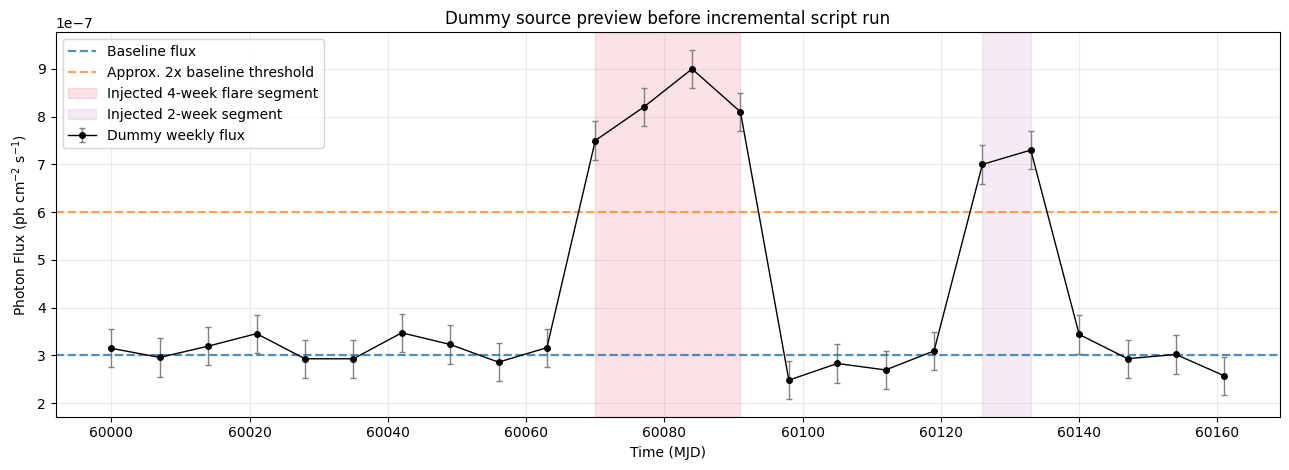

In [10]:
plot_dummy_df = dummy_df.copy() if 'dummy_df' in globals() else pd.read_csv(DUMMY_FULL_DB_PATH)

plot_dummy_df['mjd'] = npipe.MJDREFI + (plot_dummy_df['tmin'].astype(float) / npipe.SECS_IN_DAY)

fig_dummy, ax_dummy = plt.subplots(figsize=(13, 4.8))
ax_dummy.errorbar(
    plot_dummy_df['mjd'],
    plot_dummy_df['photon_flux2'],
    yerr=plot_dummy_df['photon_flux_error2'],
    fmt='o-',
    color='black',
    ecolor='gray',
    linewidth=1.0,
    markersize=4,
    capsize=2,
    label='Dummy weekly flux',
)

threshold_guess = 2.0 * baseline_flux
ax_dummy.axhline(
    baseline_flux,
    color='tab:blue',
    linestyle='--',
    linewidth=1.6,
    alpha=0.8,
    label='Baseline flux',
)
ax_dummy.axhline(
    threshold_guess,
    color='tab:orange',
    linestyle='--',
    linewidth=1.6,
    alpha=0.7,
    label='Approx. 2x baseline threshold',
)

ax_dummy.axvspan(
    plot_dummy_df['mjd'].iloc[10],
    plot_dummy_df['mjd'].iloc[13],
    color='crimson',
    alpha=0.12,
    label='Injected 4-week flare segment',
)
ax_dummy.axvspan(
    plot_dummy_df['mjd'].iloc[18],
    plot_dummy_df['mjd'].iloc[19],
    color='purple',
    alpha=0.08,
    label='Injected 2-week segment',
)

ax_dummy.set_title('Dummy source preview before incremental script run')
ax_dummy.set_xlabel('Time (MJD)')
ax_dummy.set_ylabel(r'Photon Flux (ph cm$^{-2}$ s$^{-1}$)')
ax_dummy.grid(alpha=0.25)
ax_dummy.legend(loc='upper left', frameon=True)
fig_dummy.tight_layout()

print(f'Weeks: {len(plot_dummy_df)}')
print(f'Max flux / baseline: {plot_dummy_df["photon_flux2"].max() / baseline_flux:.2f}x')
fig_dummy

## 7b. Quick Visual Check Before Running the Script
Plot the synthetic source first to confirm it has a realistic baseline plus flare-like segments worth testing.

In [11]:
if DUMMY_CACHE_PATH.exists():
    DUMMY_CACHE_PATH.unlink()

safe_dummy_name = DUMMY_SOURCE.replace(' ', '_').replace('/', '_')
scan_output_path = ROOT / 'DownloadedLC' / 'incremental' / f'{safe_dummy_name}_incremental_scan.csv'

weekly_results = []
for week_count in range(6, n_weeks + 1):
    week_db_path = DUMMY_DIR / f'dummy_week_{week_count:02d}.csv'
    dummy_df.iloc[:week_count].to_csv(week_db_path, index=False)

    cmd = [
        sys.executable,
        str(ROOT / 'AutomatedScript.py'),
        '--mode', 'incremental',
        '--source', DUMMY_SOURCE,
        '--db-path', str(week_db_path),
        '--qb-cache-path', str(DUMMY_CACHE_PATH),
        '--incremental-percent', str(PERCENT),
        '--flare-threshold-multiplier', str(FLARE_THRESHOLD_MULTIPLIER),
        '--consecutive-points', str(CONSECUTIVE_POINTS),
    ]
    completed = subprocess.run(cmd, capture_output=True, text=True, check=True)

    run_df = pd.read_csv(scan_output_path)
    latest = run_df.iloc[-1]
    weekly_results.append(
        {
            'week_count': week_count,
            'new_point_mjd': float(latest['new_point_mjd']),
            'new_point_flux': float(latest['new_point_flux']),
            'flare_flux_threshold': float(latest['flare_flux_threshold']) if pd.notna(latest['flare_flux_threshold']) else np.nan,
            'potential_flare_point': bool(latest['potential_flare_point']),
            'consecutive_potential_flare_points': int(latest['consecutive_potential_flare_points']),
            'flare_active': bool(latest['flare_active']),
            'qb_origin': str(latest['quiescent_background_origin']),
            'script_summary': completed.stdout.splitlines()[0] if completed.stdout else '',
        }
    )

weekly_results_df = pd.DataFrame(weekly_results)
weekly_results_df

,week_count,new_point_mjd,new_point_flux,flare_flux_threshold,potential_flare_point,consecutive_potential_flare_points,flare_active,qb_origin,script_summary
0,6,60035.0,2.929759e-07,NaN,False,0,False,computed,"4FGL DUMMY J9999.9+9999: weeks=5, potential_po..."
1,7,60042.0,3.473764e-07,NaN,False,0,False,computed,"4FGL DUMMY J9999.9+9999: weeks=6, potential_po..."
2,8,60049.0,3.230230e-07,NaN,False,0,False,computed,"4FGL DUMMY J9999.9+9999: weeks=7, potential_po..."
3,9,60056.0,2.859158e-07,NaN,False,0,False,computed,"4FGL DUMMY J9999.9+9999: weeks=8, potential_po..."
4,10,60063.0,3.162768e-07,NaN,False,0,False,computed,"4FGL DUMMY J9999.9+9999: weeks=9, potential_po..."
5,11,60070.0,7.500000e-07,NaN,False,0,False,computed,"4FGL DUMMY J9999.9+9999: weeks=10, potential_p..."
6,12,60077.0,8.200000e-07,NaN,False,0,False,computed,"4FGL DUMMY J9999.9+9999: weeks=11, potential_p..."
7,13,60084.0,9.000000e-07,NaN,False,0,False,computed,"4FGL DUMMY J9999.9+9999: weeks=12, potential_p..."
8,14,60091.0,8.100000e-07,NaN,False,0,False,computed,"4FGL DUMMY J9999.9+9999: weeks=13, potential_p..."
9,15,60098.0,2.482525e-07,6.268837e-07,False,0,False,computed,"4FGL DUMMY J9999.9+9999: weeks=14, potential_p..."


## 8. Borderline Dummy Profile (Near Threshold)
Build a second synthetic source with points close to the flare threshold to stress-test borderline behavior and potential false triggers.

Weeks: 26
Max flux / baseline: 2.04x


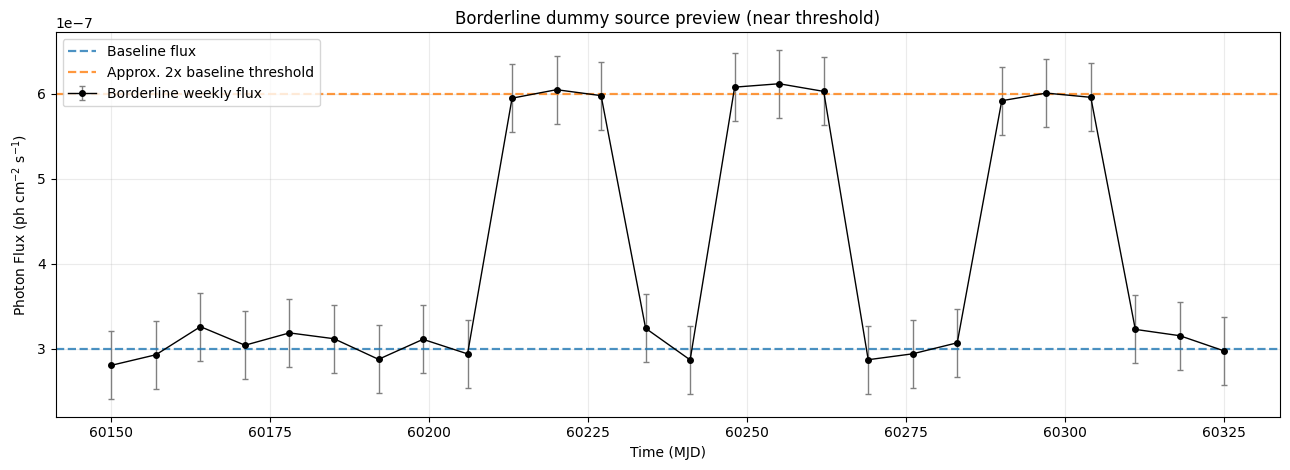

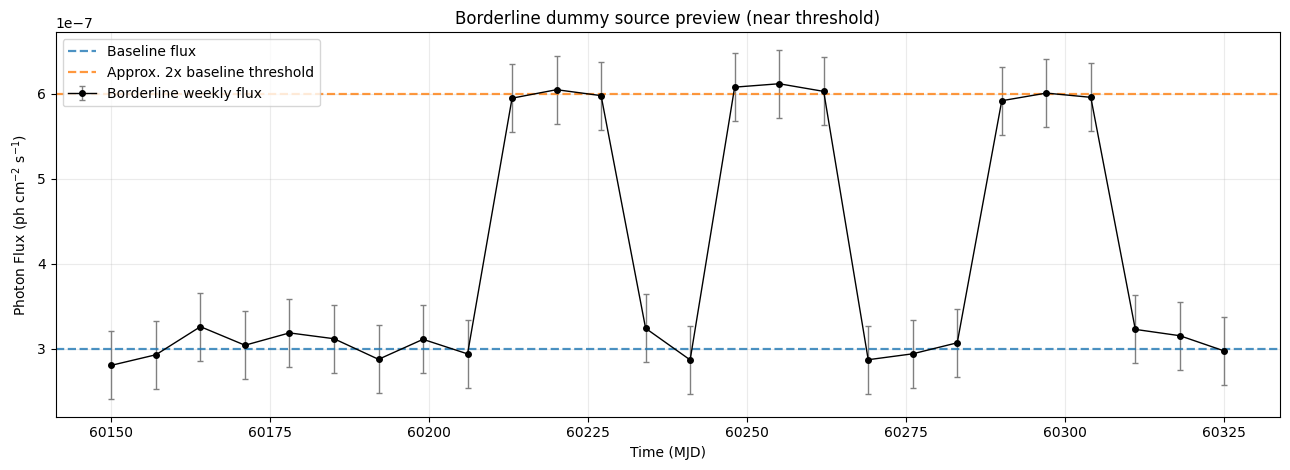

In [28]:
BORDER_SOURCE = '4FGL DUMMY BORDERLINE J9999.9+9998'
BORDER_DIR = DUMMY_DIR / 'borderline'
BORDER_DIR.mkdir(parents=True, exist_ok=True)
BORDER_CACHE_PATH = BORDER_DIR / 'borderline_qb_cache.csv'
BORDER_FULL_DB_PATH = BORDER_DIR / 'borderline_full_weekly.csv'

rng = np.random.default_rng(123)
border_n_weeks = 26
border_mjd = 60150 + np.arange(border_n_weeks) * 7.0

# Keep the profile close to the 2x-baseline line with mixed just-below/just-above runs.
border_flux = baseline_flux + rng.normal(0.0, 2.0e-8, size=border_n_weeks)
near_threshold = 2.0 * baseline_flux
border_flux[9:12] = np.array([5.95e-7, 6.05e-7, 5.98e-7])      # mixed around threshold
border_flux[14:17] = np.array([6.08e-7, 6.12e-7, 6.03e-7])     # possible 3-point borderline run
border_flux[20:23] = np.array([5.92e-7, 6.01e-7, 5.96e-7])     # mixed again
border_flux = np.clip(border_flux, 1.2e-7, None)

border_err = np.full(border_n_weeks, 4.0e-8)
border_tmin = ((border_mjd - npipe.MJDREFI) * npipe.SECS_IN_DAY).astype(float)
border_tmax = border_tmin + 7.0 * npipe.SECS_IN_DAY

border_df = pd.DataFrame(
    {
        'Unnamed: 0': np.arange(border_n_weeks),
        'source_name': BORDER_SOURCE,
        'cadence': 'weekly',
        'tmin': border_tmin,
        'tmax': border_tmax,
        'photon_flux2': border_flux,
        'photon_flux_error2': border_err,
        'photon_index2': np.full(border_n_weeks, 2.0),
        'return_code2': np.zeros(border_n_weeks, dtype=int),
        'ts2': np.full(border_n_weeks, 35.0),
    }
)
border_df.to_csv(BORDER_FULL_DB_PATH, index=False)

fig_border, ax_border = plt.subplots(figsize=(13, 4.8))
ax_border.errorbar(
    border_mjd,
    border_flux,
    yerr=border_err,
    fmt='o-',
    color='black',
    ecolor='gray',
    linewidth=1.0,
    markersize=4,
    capsize=2,
    label='Borderline weekly flux',
)
ax_border.axhline(baseline_flux, color='tab:blue', linestyle='--', linewidth=1.6, alpha=0.8, label='Baseline flux')
ax_border.axhline(near_threshold, color='tab:orange', linestyle='--', linewidth=1.6, alpha=0.8, label='Approx. 2x baseline threshold')
ax_border.set_title('Borderline dummy source preview (near threshold)')
ax_border.set_xlabel('Time (MJD)')
ax_border.set_ylabel(r'Photon Flux (ph cm$^{-2}$ s$^{-1}$)')
ax_border.grid(alpha=0.25)
ax_border.legend(loc='upper left', frameon=True)
fig_border.tight_layout()

print(f'Weeks: {len(border_df)}')
print(f'Max flux / baseline: {border_df["photon_flux2"].max() / baseline_flux:.2f}x')
fig_border

In [29]:
if BORDER_CACHE_PATH.exists():
    BORDER_CACHE_PATH.unlink()

safe_border_name = BORDER_SOURCE.replace(' ', '_').replace('/', '_')
border_scan_output_path = ROOT / 'DownloadedLC' / 'incremental' / f'{safe_border_name}_incremental_scan.csv'

border_weekly_results = []
for week_count in range(6, border_n_weeks + 1):
    week_db_path = BORDER_DIR / f'border_week_{week_count:02d}.csv'
    border_df.iloc[:week_count].to_csv(week_db_path, index=False)

    cmd = [
        sys.executable,
        str(ROOT / 'AutomatedScript.py'),
        '--mode', 'incremental',
        '--source', BORDER_SOURCE,
        '--db-path', str(week_db_path),
        '--qb-cache-path', str(BORDER_CACHE_PATH),
        '--incremental-percent', str(PERCENT),
        '--flare-threshold-multiplier', str(FLARE_THRESHOLD_MULTIPLIER),
        '--consecutive-points', str(CONSECUTIVE_POINTS),
    ]
    completed = subprocess.run(cmd, capture_output=True, text=True, check=True)

    run_df = pd.read_csv(border_scan_output_path)
    latest = run_df.iloc[-1]
    border_weekly_results.append(
        {
            'week_count': week_count,
            'new_point_mjd': float(latest['new_point_mjd']),
            'new_point_flux': float(latest['new_point_flux']),
            'flare_flux_threshold': float(latest['flare_flux_threshold']) if pd.notna(latest['flare_flux_threshold']) else np.nan,
            'potential_flare_point': bool(latest['potential_flare_point']),
            'consecutive_potential_flare_points': int(latest['consecutive_potential_flare_points']),
            'flare_active': bool(latest['flare_active']),
            'qb_origin': str(latest['quiescent_background_origin']),
        }
    )

border_weekly_results_df = pd.DataFrame(border_weekly_results)

print(f'Potential flare points: {int(border_weekly_results_df["potential_flare_point"].sum())}')
print(f'Weeks flare_active=True: {int(border_weekly_results_df["flare_active"].sum())}')

border_weekly_results_df.tail(12)

Potential flare points: 2
Weeks flare_active=True: 0


,week_count,new_point_mjd,new_point_flux,flare_flux_threshold,potential_flare_point,consecutive_potential_flare_points,flare_active,qb_origin
9,15,60248.0,6.080000e-07,6.053832e-07,True,1,False,cache
10,16,60255.0,6.120000e-07,6.053832e-07,True,2,False,cache
11,17,60262.0,6.030000e-07,6.053832e-07,False,0,False,cache
12,18,60269.0,2.868006e-07,6.053832e-07,False,0,False,cache
13,19,60276.0,2.937641e-07,6.053832e-07,False,0,False,cache
14,20,60283.0,3.067554e-07,6.053832e-07,False,0,False,cache
15,21,60290.0,5.920000e-07,6.053832e-07,False,0,False,cache
16,22,60297.0,6.010000e-07,6.053832e-07,False,0,False,cache
17,23,60304.0,5.960000e-07,6.053832e-07,False,0,False,cache
18,24,60311.0,3.225361e-07,6.053832e-07,False,0,False,cache
